/Users/dariogreco/STAT946/CS2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Training LASSO Baseline with Cross-Validation...
Optimal LASSO alpha found: 0.003347
Running N-HiTS Inference...

--- TEST SET RESULTS ---
LASSO RMSE:  6.7843
N-HiTS RMSE: 6.7347

Showdown plot saved as nhits_vs_lasso_plot.png!


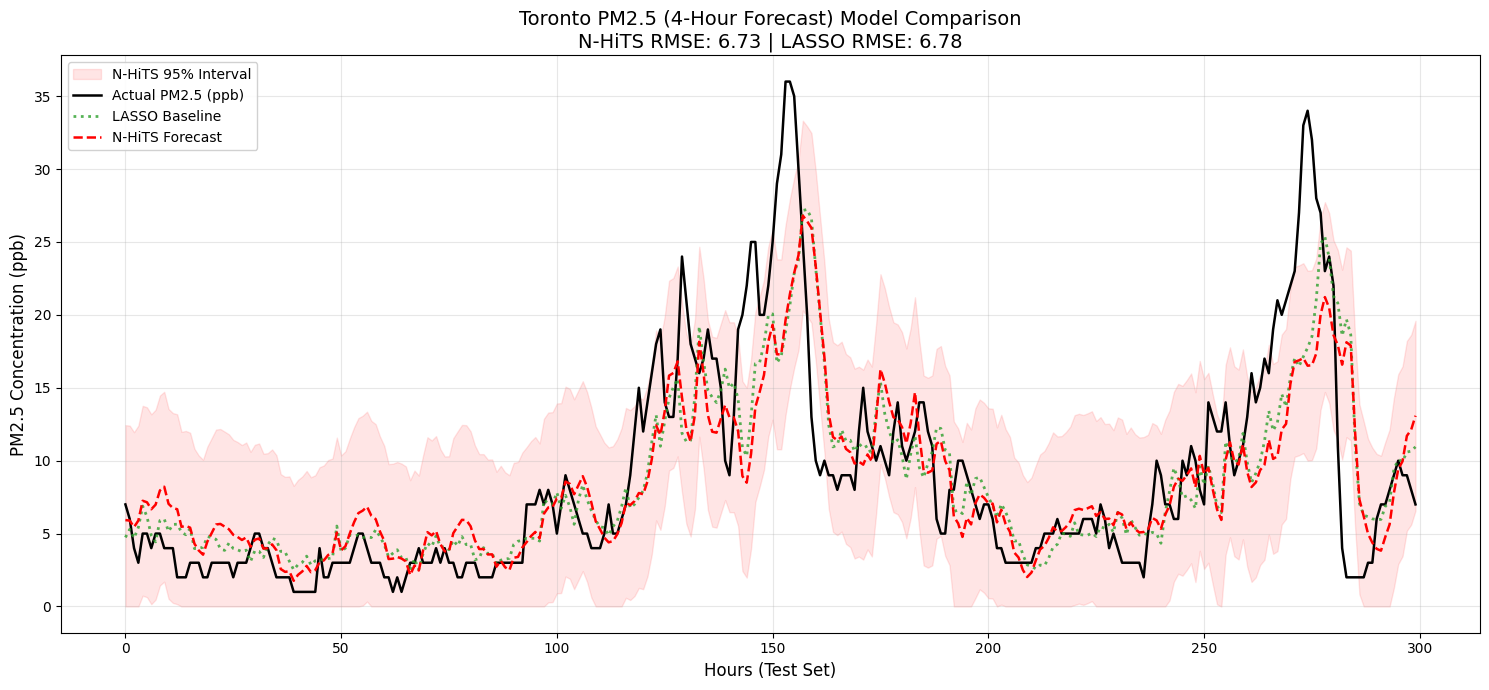

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# ==========================================
# 1. NEW N-HITS ARCHITECTURE & DATASET
# ==========================================

class NHITSBlock(nn.Module):
    def __init__(self, input_dim, seq_len, max_horizon, pool_size, n_theta, hidden_dim, dropout_rate):
        super().__init__()
        self.pool_size = pool_size
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.max_horizon = max_horizon

        self.pooled_seq_len = int(np.ceil(seq_len / pool_size))
        flat_dim = input_dim * self.pooled_seq_len

        self.mlp = nn.Sequential(
            nn.Linear(flat_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1)
        )

        self.theta_b = nn.Linear(hidden_dim, seq_len * input_dim)
        self.theta_f = nn.Linear(hidden_dim, n_theta)

    def forward(self, x):
        x_pool = x.permute(0, 2, 1) 
        if self.pool_size > 1:
            x_pool = F.max_pool1d(x_pool, kernel_size=self.pool_size, stride=self.pool_size, ceil_mode=True)

        h = self.mlp(x_pool.reshape(x_pool.size(0), -1))
        backcast = self.theta_b(h).reshape(-1, self.seq_len, self.input_dim)
        
        theta_f = self.theta_f(h).unsqueeze(1) 
        forecast = F.interpolate(theta_f, size=self.max_horizon, mode='linear', align_corners=True).squeeze(1)

        return backcast, forecast

class RealNHITS(nn.Module):
    def __init__(self, input_dim, seq_len, hidden_dim=256, dropout_rate=0.1):
        super().__init__()
        self.max_horizon = 24 
        
        self.block1 = NHITSBlock(input_dim, seq_len, self.max_horizon, 4, 6, hidden_dim, dropout_rate)
        self.block2 = NHITSBlock(input_dim, seq_len, self.max_horizon, 2, 12, hidden_dim, dropout_rate)
        self.block3 = NHITSBlock(input_dim, seq_len, self.max_horizon, 1, 24, hidden_dim, dropout_rate)

    def forward(self, x):
        exog = x[:, :, 1:] 
        target = x[:, :, 0:1] 

        b1, f1 = self.block1(x)
        res_target = target - b1[:, :, 0:1] 

        input_2 = torch.cat([res_target, exog], dim=-1)
        b2, f2 = self.block2(input_2)
        res_target = res_target - b2[:, :, 0:1]

        input_3 = torch.cat([res_target, exog], dim=-1)
        _, f3 = self.block3(input_3)

        return (f1 + f2 + f3)[:, 3]

class AQDataset(Dataset):
    def __init__(self, data, seq_len, horizon=4):
        self.data = data
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon

    def __getitem__(self, idx):
        x = torch.FloatTensor(self.data[idx : idx + self.seq_len])
        y = torch.FloatTensor([self.data[idx + self.seq_len + self.horizon - 1, 0]])
        return x, y

# ==========================================
# 2. LOCAL INFERENCE & PLOTTING
# ==========================================

if __name__ == "__main__":
    device = torch.device("cpu") 
    
    # --- LOAD DATA ---
    data_path = "data/data_clean/cleaned_data_toronto_downtown.csv" 
    df = pd.read_csv(data_path, low_memory=False)
    features = ['PM_ppb', 'Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Stn Press (kPa)', 'Dew Point Temp (°C)', 'Precip. Amount (mm)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
    
    # 1. STRICT NO-LEAKAGE SCALING
    train_size = int(len(df) * 0.7)
    scaler = StandardScaler()
    scaler.fit(df.iloc[:train_size][features])
    scaled_data_array = scaler.transform(df[features].values)
    pm_mean, pm_std_scaler = scaler.mean_[0], scaler.scale_[0]

    # --- CHAMPION HYPERPARAMETERS ---
    BEST_LOOKBACK = 24  
    BEST_HIDDEN = 512   
    BEST_DROP = 0.1
    
    # --- BUILD DATASETS ---
    dataset = AQDataset(scaled_data_array, seq_len=BEST_LOOKBACK)
    n = len(dataset)
    train_idx, val_idx = int(0.7 * n), int(0.85 * n)
    
    val_loader = DataLoader(Subset(dataset, range(train_idx, val_idx)), batch_size=128)
    test_loader = DataLoader(Subset(dataset, range(val_idx, n)), batch_size=128)

# ==========================================
    # 3. LASSO BASELINE TRAINING (WITH CV)
    # ==========================================
    print("Training LASSO Baseline with Cross-Validation...")
    
    # Flatten the lookback windows for SKLearn
    X_all, y_all = [], []
    for i in range(n):
        X_all.append(scaled_data_array[i : i + BEST_LOOKBACK].flatten())
        y_all.append(scaled_data_array[i + BEST_LOOKBACK + 3, 0]) # 4th hour target
    
    X_all = np.array(X_all)
    y_all = np.array(y_all)
    
    X_train_lasso = X_all[:train_idx]
    y_train_lasso = y_all[:train_idx]
    X_test_lasso = X_all[val_idx:]
    
    # TimeSeriesSplit ensures no future-data leakage during cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    
    # LassoCV automatically sweeps the alpha penalty using the time-series folds
    # max_iter is increased to ensure convergence on small alphas
    lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000, n_jobs=-1)
    lasso.fit(X_train_lasso, y_train_lasso)
    
    print(f"Optimal LASSO alpha found: {lasso.alpha_:.6f}")
    
    # Predict and Unscale
    lasso_preds_raw = lasso.predict(X_test_lasso)
    lasso_preds = (lasso_preds_raw * pm_std_scaler) + pm_mean

    # ==========================================
    # 4. N-HITS INFERENCE & UNCERTAINTY
    # ==========================================
    print("Running N-HiTS Inference...")
    model = RealNHITS(input_dim=11, seq_len=BEST_LOOKBACK, hidden_dim=BEST_HIDDEN, dropout_rate=BEST_DROP)
    model.load_state_dict(torch.load("global_champion_nhits.pt", map_location=device))
    model.eval()

    # Val Set (for Uncertainty)
    val_preds, val_actuals = [], []
    with torch.no_grad():
        for x, y in val_loader:
            val_preds.append(model(x).numpy().flatten()) 
            val_actuals.append(y.numpy().flatten())
            
    val_residuals = np.concatenate(val_actuals) - np.concatenate(val_preds)
    unscaled_residual_std = np.std(val_residuals) * pm_std_scaler
    margin_of_error = 1.96 * unscaled_residual_std

    # Test Set
    test_preds, test_actuals = [], []
    with torch.no_grad():
        for x, y in test_loader:
            test_preds.append(model(x).numpy().flatten())
            test_actuals.append(y.numpy().flatten())
            
    unscaled_preds = (np.concatenate(test_preds) * pm_std_scaler) + pm_mean
    unscaled_actuals = (np.concatenate(test_actuals) * pm_std_scaler) + pm_mean
    
    upper_bound = unscaled_preds + margin_of_error
    lower_bound = np.maximum(unscaled_preds - margin_of_error, 0)

    # ==========================================
    # 5. PLOT THE SHOWDOWN
    # ==========================================
    nhits_rmse = np.sqrt(mean_squared_error(unscaled_actuals, unscaled_preds))
    lasso_rmse = np.sqrt(mean_squared_error(unscaled_actuals, lasso_preds))
    
    print(f"\n--- TEST SET RESULTS ---")
    print(f"LASSO RMSE:  {lasso_rmse:.4f}")
    print(f"N-HiTS RMSE: {nhits_rmse:.4f}")

    PLOT_LENGTH = 300
    time_axis = np.arange(PLOT_LENGTH)
    
    plt.figure(figsize=(15, 7))
    
    # N-HiTS Uncertainty Band
    plt.fill_between(time_axis, lower_bound[:PLOT_LENGTH], upper_bound[:PLOT_LENGTH], color='red', alpha=0.1, label='N-HiTS 95% Interval')
    
    # The Lines
    plt.plot(time_axis, unscaled_actuals[:PLOT_LENGTH], label="Actual PM2.5 (ppb)", color='black', linewidth=1.8)
    plt.plot(time_axis, lasso_preds[:PLOT_LENGTH], label=f"LASSO Baseline", color='#2ca02c', linestyle=':', linewidth=2, alpha=0.8)
    plt.plot(time_axis, unscaled_preds[:PLOT_LENGTH], label=f"N-HiTS Forecast", color='red', linestyle='--', linewidth=1.8)
    
    plt.title(f"Toronto PM2.5 (4-Hour Forecast) Model Comparison\nN-HiTS RMSE: {nhits_rmse:.2f} | LASSO RMSE: {lasso_rmse:.2f}", fontsize=14)
    plt.xlabel("Hours (Test Set)", fontsize=12)
    plt.ylabel("PM2.5 Concentration (ppb)", fontsize=12)
    plt.legend(loc="upper left", framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.savefig("nhits_vs_lasso_plot.png", dpi=300)
    print("\nShowdown plot saved as nhits_vs_lasso_plot.png!")